In [1]:
import os
os.chdir("../")
configs_file = "train_debug"

In [2]:
import os
from functools import partial

import equinox as eqx
import jax
# jax.config.update("jax_default_matmul_precision", "float32") 
import jax.numpy as jnp
import matplotlib.pyplot as plt
from einops import rearrange, reduce, repeat

from ice_melting.configs import load_configs
configs = load_configs(configs_file)


from ggsci import pal_npg, pal_gsea
colors = pal_npg()(10)
import seaborn as sns
from matplotlib import font_manager
font_dir = "./helvetica/"
font_names = os.listdir(font_dir)
for font_name in font_names:
    font_manager.fontManager.addfont(font_dir + font_name)
# nature style
from matplotlib import rcParams
rcParams.update({
    "font.size": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica",],
    "pdf.fonttype": 42,
    "figure.dpi": 300,
    "xtick.direction": "in",
    "ytick.direction": "in",
    # thin ticks
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    # thin axes
    "axes.linewidth": 0.5,
    # thin legend frame
    "legend.frameon": False,
    # set color_theme as ggsci
    "axes.prop_cycle": plt.cycler(color=[
        "#E64B35", "#4DBBD5", "#00A087",
        "#3C5488", "#F39B7F", "#8491B4",
        "#91D1C2", "#DC0000", "#7E6148", "#B09C85"
    ]),
    # "axes.prop_cycle": plt.cycler(color=colors),
})

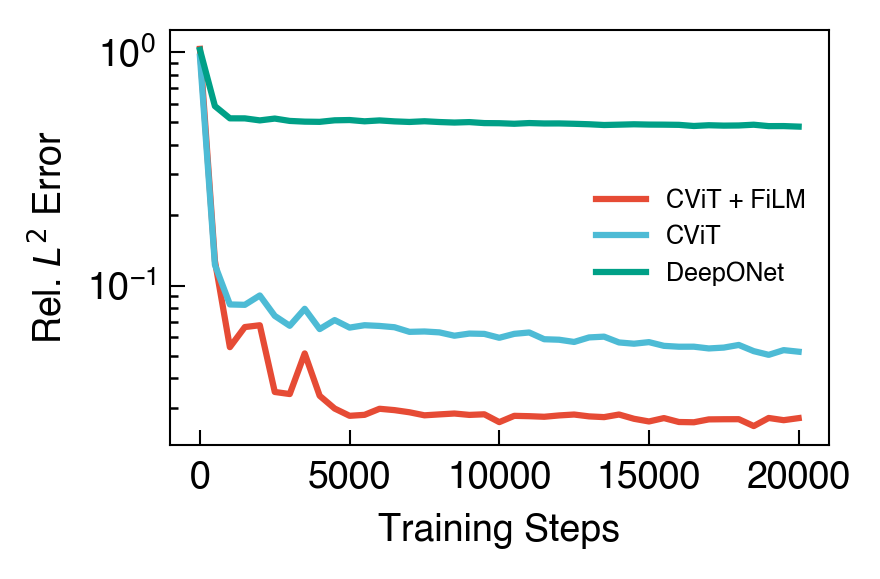

In [3]:
import pandas as pd
paths = [
    "ice_melting/logs/run-ice_melting_ellipse_cvit_xffe_tffe_film-tag-eval_l2_error.csv",
    "ice_melting/logs/run-ice_melting_ellipse_cvit_x_emb-t_emb-concatenate-tag-eval_l2_error.csv",
    "ice_melting/logs/run-ice_melting_ellipse_deeponet_20260103-143121-tag-eval_l2_error.csv",
]

labels = ["CViT + FiLM", "CViT", "DeepONet"]

fig, ax = plt.subplots(figsize=(3, 2))
for path, label in zip(paths, labels):
    df = pd.read_csv(path)
    ax.plot(df["Step"], df["Value"],label=label)

ax.set_yscale("log")
ax.set_xlabel("Training Steps")
ax.set_ylabel(r"Rel. $L^2$ Error")
ax.legend(frameon=False, fontsize=6)
fig.tight_layout()
fig.savefig("./figures/ice_melting_l2_error.svg", dpi=300, bbox_inches="tight", pad_inches=0)

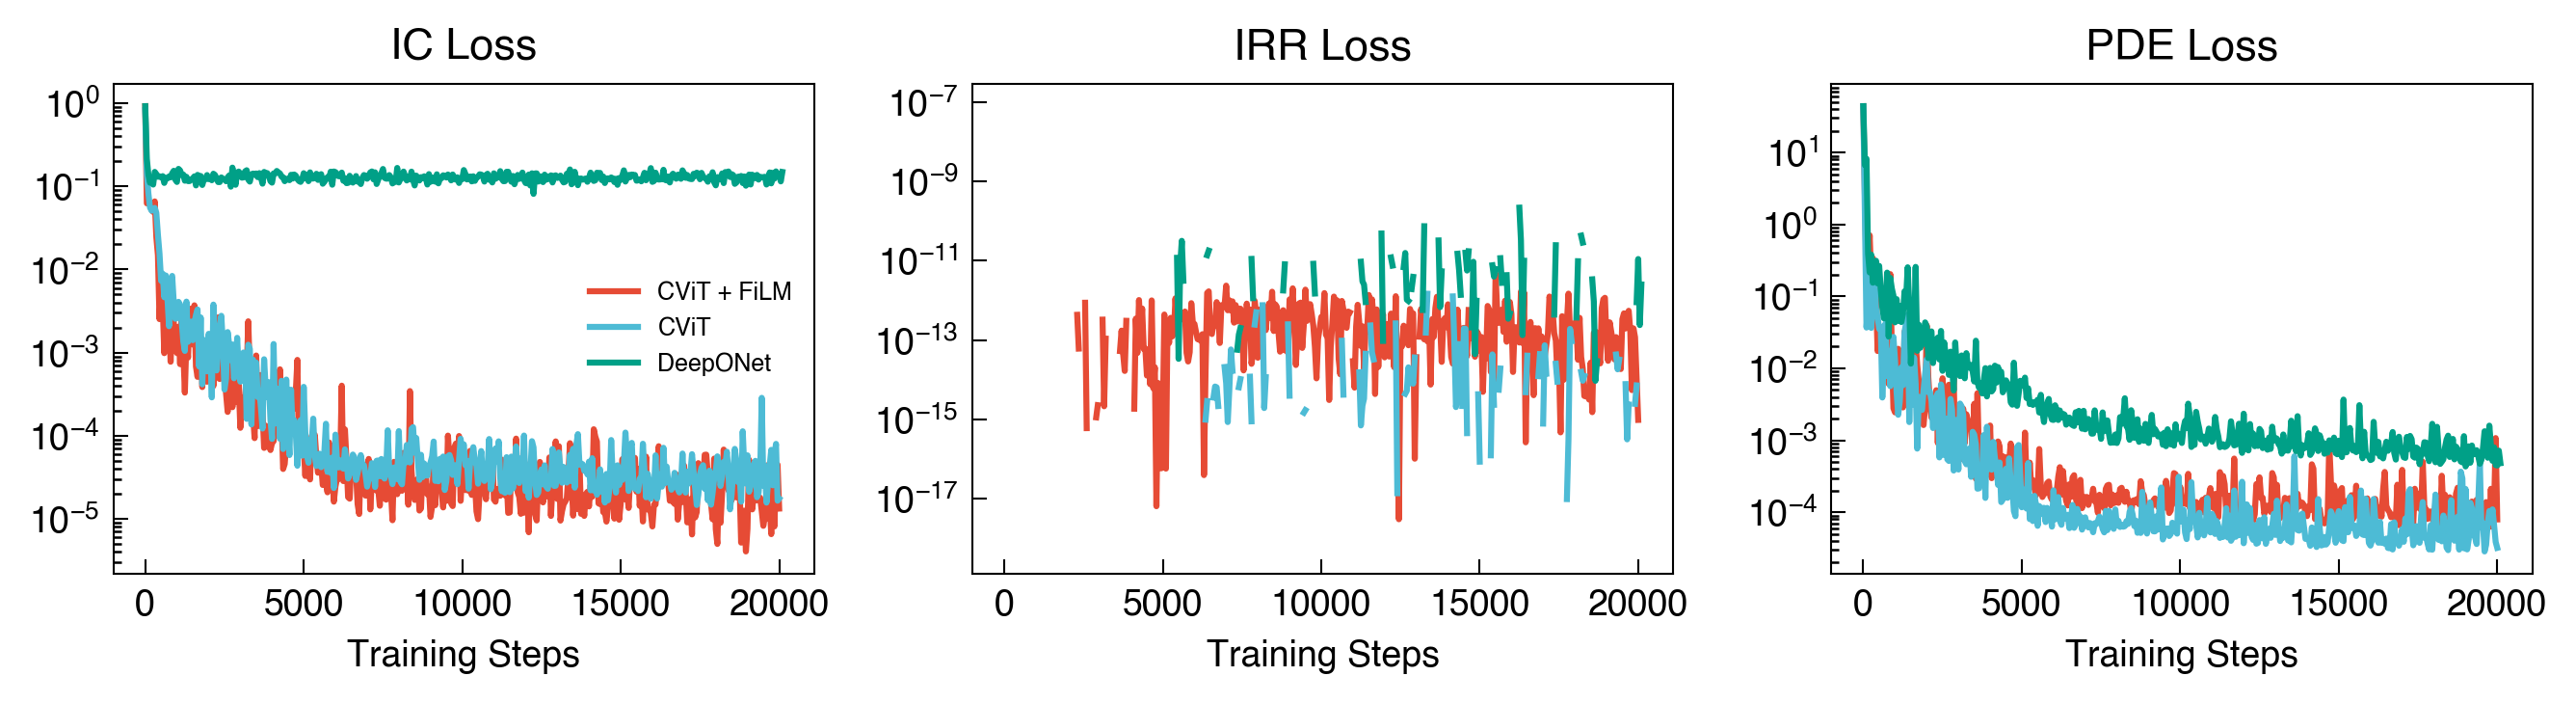

In [4]:
import pandas as pd
paths = [
    "ice_melting/logs/run-ice_melting_ellipse_cvit_xffe_tffe_film-tag-loss_loss_{}.csv",
    "ice_melting/logs/run-ice_melting_ellipse_cvit_x_emb-t_emb-concatenate-tag-loss_loss_{}.csv",
    "ice_melting/logs/run-ice_melting_ellipse_deeponet_20260103-143121-tag-loss_loss_{}.csv",
]

labels = ["CViT + FiLM", "CViT", "DeepONet"]
loss_types = ["ic", "irr", "pde"]

fig, axes = plt.subplots(1, 3, figsize=(9, 2.5),)
for i, (ax, loss_type) in enumerate(zip(axes, loss_types)):
    for path, label in zip(paths, labels):
        df = pd.read_csv(path.format(loss_type))
        # fill 0 as nan
        idxs = df["Value"] == 0
        df.loc[idxs, "Value"] = jnp.nan
        ax.plot(df["Step"], df["Value"],label=label)

        ax.set_yscale("log")
        ax.set_xlabel("Training Steps")
        ax.set_title(loss_type.upper() + " Loss")
        if i == 0:
            ax.legend(frameon=False, fontsize=6)

fig.tight_layout()
fig.savefig("./figures/ice_melting_losses.svg", dpi=300, bbox_inches="tight", pad_inches=0)